In [ ]:
import os
import sys

import rdflib
import numpy as np
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

# Set project root (one level above notebooks/) and ensure src/ is importable
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
os.chdir(PROJECT_ROOT)
sys.path.insert(0, os.path.join(PROJECT_ROOT, "src"))

from images2action.nb_config import load_experiment_config

cfg = load_experiment_config("config/train.yaml")

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

In [3]:
############################################
# 1️⃣ Load RDF Graph
############################################
schema_path = cfg["data"]["schema_path"]
bdd_100k_val_path = cfg["data"]["bdd_ttl"]
coco_traffic_val_path = cfg["data"]["coco_ttl"]

print(f"Schema.ttl exists? {os.path.exists(schema_path)}")
print(f"bdd_100k_val.ttl exists? {os.path.exists(bdd_100k_val_path)}")
print(f"coco_traffic_val.ttl exists? {os.path.exists(coco_traffic_val_path)}")

print("Loading RDF graphs...")


g = rdflib.Graph()
g.parse(schema_path, format="turtle")
g.parse(bdd_100k_val_path, format="turtle")
g.parse(coco_traffic_val_path, format="turtle")

print(f"Graph loaded with {len(g)} triples")

############################################
# 2️⃣ SPARQL Query
############################################

query = cfg["query"]["text"]
results = g.query(query)

Schema.ttl exists? True
bdd_100k_val.ttl exists? True
coco_traffic_val.ttl exists? True
Loading RDF graphs...
Graph loaded with 226652 triples


In [4]:
data = []
for row in results:
    path = str(row.path)
    action = str(row.action)
    data.append((path, action))

print(f"Total samples from KG: {len(data)}")

Total samples from KG: 328


In [5]:
############################################
# 3️⃣ Convert URIs → Numeric Labels
############################################

# Extract unique actions
unique_actions = sorted(list(set([a for _, a in data])))

label_map = {uri: idx for idx, uri in enumerate(unique_actions)}
idx_to_label = {v: k for k, v in label_map.items()}

print("\nLabel Mapping:")
for k, v in label_map.items():
    print(f"{k.split('/')[-1]} → {v}")

# Convert dataset
dataset = [(path, label_map[action]) for path, action in data]


Label Mapping:
GoAction → 0
SlowAction → 1
StopAction → 2
UnknownAction → 3


In [6]:
len(dataset)

328

In [7]:
dataset[0]

('data/bdd_100k_val/images/b1c66a42-6f7d68ca.jpg', 0)

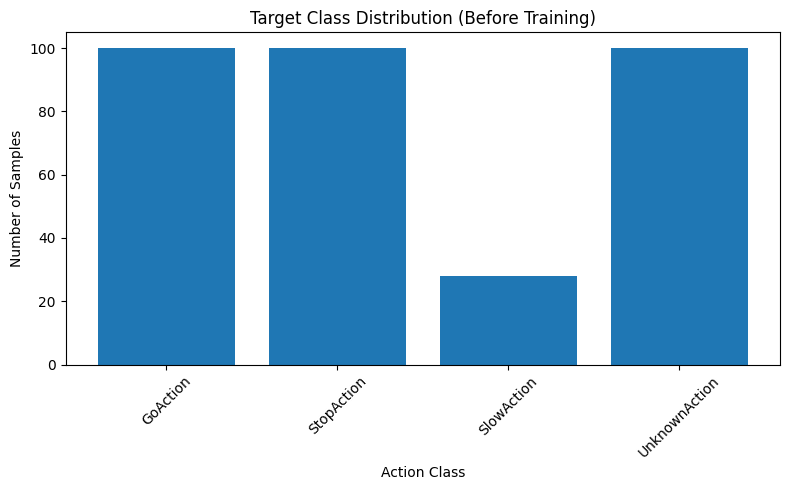

In [8]:
# Extract labels
labels = [label for _, label in dataset]

# Count occurrences
label_counts = Counter(labels)

# Convert to readable names
class_names = [idx_to_label[i].split('/')[-1] for i in label_counts.keys()]
counts = list(label_counts.values())

# Plot
plt.figure(figsize=(8,5))
plt.bar(class_names, counts)
plt.xticks(rotation=45)
plt.title("Target Class Distribution (Before Training)")
plt.xlabel("Action Class")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

In [9]:
############################################
# 4️⃣ Train/Test Split
############################################

train_data, val_data = train_test_split(
    dataset,
    test_size=cfg["training"]["val_split"],
    random_state=cfg["training"]["seed"],
)

In [ ]:
############################################
# 5️⃣ PyTorch Dataset
############################################

class KGImageDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        path, label = self.data[idx]

        if not os.path.exists(path):
            raise FileNotFoundError(f"Image not found: {path}")

        image = Image.open(path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

def plot_confusion_matrix(model, loader, save_path=None):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    print(unique_actions)
    print(idx_to_label)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, 
                annot=True, 
                fmt="d", 
                xticklabels=[idx_to_label[i].split('/')[-1] for i in range(len(unique_actions))],
                yticklabels=[idx_to_label[i].split('/')[-1] for i in range(len(unique_actions))],
                cmap="Blues")
    
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")
    plt.show()

In [11]:
train_dataset = KGImageDataset(train_data, transform)
val_dataset = KGImageDataset(val_data, transform)

batch_size = cfg["training"]["batch_size"]
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

In [12]:
train_dataset[0]

(tensor([[[-1.9295, -1.9295, -1.9295,  ..., -1.8782, -1.8610, -1.8953],
          [-1.9467, -1.9467, -1.9467,  ..., -1.8782, -1.8610, -1.8782],
          [-1.9809, -1.9809, -1.9638,  ..., -1.8953, -1.8782, -1.8953],
          ...,
          [-2.0665, -2.0837, -2.0665,  ..., -2.0323, -2.0323, -2.0323],
          [-2.0494, -2.0665, -2.0665,  ..., -2.0494, -2.0494, -1.9980],
          [-2.0323, -2.0494, -2.0323,  ..., -2.0665, -2.0837, -1.9467]],
 
         [[-1.9482, -1.9307, -1.9307,  ..., -1.7906, -1.7906, -1.8256],
          [-1.9482, -1.9307, -1.9307,  ..., -1.7906, -1.7906, -1.8081],
          [-1.9307, -1.9307, -1.9132,  ..., -1.8081, -1.8256, -1.8256],
          ...,
          [-1.9657, -1.9832, -1.9832,  ..., -1.9657, -1.9657, -1.9657],
          [-1.9657, -1.9657, -1.9832,  ..., -1.9832, -1.9832, -1.9307],
          [-1.9482, -1.9482, -1.9482,  ..., -2.0182, -2.0007, -1.8782]],
 
         [[-1.6476, -1.6302, -1.6127,  ..., -1.6650, -1.5779, -1.6650],
          [-1.6476, -1.6476,

In [13]:
############################################
# 6️⃣ Model Setup (Transfer Learning)
############################################

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=True)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(unique_actions))

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=cfg["training"]["learning_rate"])

print(f"Using device: {device}")
print(f"Run name: {cfg['output']['run_name']}")

c:\Users\kaleem\Learn\FUB\WiSe_2025_26\Knowledge Graphs and AI Apps\kgnai\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\kaleem\Learn\FUB\WiSe_2025_26\Knowledge Graphs and AI Apps\kgnai\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [14]:
############################################
# 7️⃣ Training Loop
############################################

import json
from datetime import datetime

def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total


EPOCHS = cfg["training"]["num_epochs"]

os.makedirs(cfg["output"]["model_dir"], exist_ok=True)
os.makedirs(cfg["output"]["metrics_dir"], exist_ok=True)
os.makedirs(cfg["output"]["figures_dir"], exist_ok=True)

run_name = cfg["output"]["run_name"]

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0

    for images, labels in tqdm(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    val_acc = evaluate(model, val_loader)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Training Loss: {running_loss:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")

# Save final model and metrics
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_path = os.path.join(cfg["output"]["model_dir"], f"{run_name}_{timestamp}.pt")

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "label_map": label_map,
        "idx_to_label": idx_to_label,
        "config": cfg,
    },
    model_path,
)

metrics = {
    "epochs": EPOCHS,
    "val_accuracy": float(val_acc),
    "train_loss_last_epoch": float(running_loss),
}

metrics_path = os.path.join(cfg["output"]["metrics_dir"], f"{run_name}_{timestamp}_metrics.json")
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

print(f"\nSaved model to {model_path}")
print(f"Saved metrics to {metrics_path}")

100%|██████████| 9/9 [00:31<00:00,  3.55s/it]



Epoch 1/5
Training Loss: 12.5824
Validation Accuracy: 0.4394


100%|██████████| 9/9 [00:26<00:00,  2.90s/it]



Epoch 2/5
Training Loss: 4.5700
Validation Accuracy: 0.4242


100%|██████████| 9/9 [00:25<00:00,  2.80s/it]



Epoch 3/5
Training Loss: 1.9026
Validation Accuracy: 0.4545


100%|██████████| 9/9 [00:25<00:00,  2.87s/it]



Epoch 4/5
Training Loss: 1.0130
Validation Accuracy: 0.4242


100%|██████████| 9/9 [00:25<00:00,  2.81s/it]



Epoch 5/5
Training Loss: 0.4291
Validation Accuracy: 0.4091


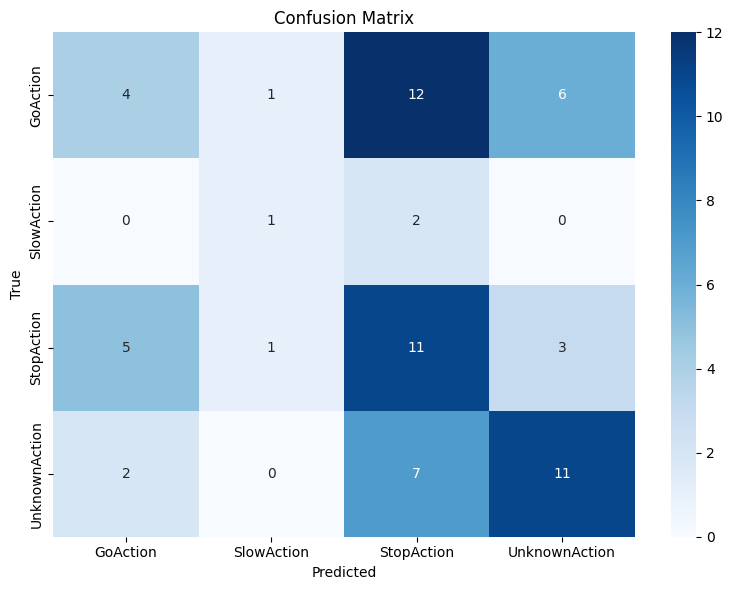

In [15]:
conf_mat_path = os.path.join(
    cfg["output"]["figures_dir"],
    f"{cfg['output']['run_name']}_confusion_matrix.png",
)
plot_confusion_matrix(model, val_loader, save_path=conf_mat_path)
print(f"Saved confusion matrix to {conf_mat_path}")

In [16]:
os.path.exists("data/coco_traffic_val/images/000000345786.jpg")

True